In [ ]:
: 5 ; limiar para treinar um novo discriminador:
0,7 ; tamanho da fila de discriminadores: 6 ; ´area de busca: 12 pixels (Essa quantidade de pixels ´e utilizada para criar a janela de busca, aumentando-se o retˆangulo
que envolve o alvo, com essa quantidade de pixels para cada um dos lados)

In [ ]:
import sys
import os
import cv2
sys.path.insert(0, os.path.abspath(".."))

# --- Caminhos do Dataset ---
DATASET_ROOT_FOLDER = '../../data/tiger2'
IMAGE_FOLDER = os.path.join(DATASET_ROOT_FOLDER, 'imgs')
GT_TXT_PATH = os.path.join(DATASET_ROOT_FOLDER, 'tiger2_gt.txt')

In [ ]:
def display_frames_with_bbox(bbox, frame, frame_path):
    # Desenha o bounding box inicial no frame
    x, y, w, h = map(int, bbox)

    # Garante que as coordenadas são válidas para desenhar
    x = max(0, x)
    y = max(0, y)
    w = max(1, w)
    h = max(1, h)

    # Ajusta para não ultrapassar as bordas da imagem
    w = min(w, frame.shape[1] - x)
    h = min(h, frame.shape[0] - y)

    if w > 0 and h > 0:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2) # Cor verde, espessura 2
        cv2.putText(frame, "Initial BBox", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        print(f"BBox inicial: ({x}, {y}, {w}, {h}) no frame: {os.path.basename(frame_path)}")
    else:
        print(f"Aviso: BBox inicial inválido após ajuste: ({x}, {y}, {w}, {h}). Não será desenhado.")


    # Exibe a imagem
    cv2.imshow('First Frame with Initial BBox', frame)
    print("Pressione qualquer tecla para fechar a janela.")
    cv2.waitKey(0) # Espera por uma tecla
    cv2.destroyAllWindows() # Fecha a janela


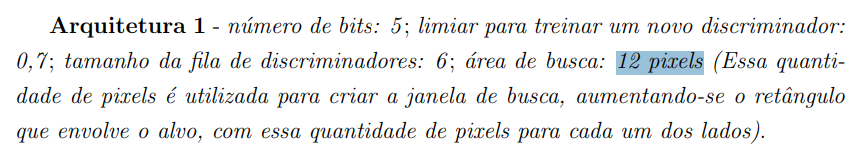

In [ ]:
from tracker.cluswisard_tracker import ClusWisardTracker

parameters = {
    'INPUT_PATTERN_SIDE': 32,
    'SEARCH_WINDOW_SCALE': 1.5,
    'NUM_SEARCH_SAMPLES': 500,
    'CLUSAZARD_ADDRESS_SIZE': 5,
    'CLUSAZARD_MIN_SCORE': 0.7,
    'CLUSAZARD_THRESHOLD': 5,
    'CLUSAZARD_DISCRIMINATOR_LIMIT': 5,
    'CLUSAZARD_BLEACHING_ACTIVATED': False,
    'CLUSAZARD_ACTIVATION_DEGREE': True,
    'CLUSAZARD_RETURN_CONFIDENCE': False,
    'CLUSAZARD_CLASSES_DEGREES': False
}

tracker = ClusWisardTracker(IMAGE_FOLDER, GT_TXT_PATH, parameters)
resultados = tracker.track()


In [ ]:
from tracker.cluswisard_tracker import ClusWisardTracker

parameters = {
    'INPUT_PATTERN_SIDE': 32,
    'SEARCH_WINDOW_SCALE': 10,
    'NUM_SEARCH_SAMPLES': 1000,
    'CLUSAZARD_ADDRESS_SIZE': 2,
    'CLUSAZARD_MIN_SCORE': 0.9,
    'CLUSAZARD_THRESHOLD': 5,
    'CLUSAZARD_DISCRIMINATOR_LIMIT': 1,
    'CLUSAZARD_BLEACHING_ACTIVATED': False,
    'CLUSAZARD_ACTIVATION_DEGREE': True,
    'CLUSAZARD_RETURN_CONFIDENCE': False,
    'CLUSAZARD_CLASSES_DEGREES': False
}

tracker = ClusWisardTracker(IMAGE_FOLDER, GT_TXT_PATH, parameters) # GT_TXT_PATH aqui pode ser um dummy se o tracker já incorpora o GT
resultados = tracker.track()

def draw_bbox(frame, bbox, color, label):
    """
    Desenha um bounding box no frame.
    Args:
        frame: O frame da imagem.
        bbox: O bounding box no formato (x, y, w, h).
        color: A cor do bounding box (B, G, R).
        label: O rótulo de texto para o bounding box.
    """
    if bbox is None or all(coord == 0 for coord in bbox):
        return

    x, y, w, h = map(int, bbox)

    # Garante que as coordenadas são válidas para desenhar
    x = max(0, x)
    y = max(0, y)
    w = max(1, w)
    h = max(1, h)

    # Ajusta para não ultrapassar as bordas da imagem
    w = min(w, frame.shape[1] - x)
    h = min(h, frame.shape[0] - y)

    if w > 0 and h > 0:
        cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)
        cv2.putText(frame, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    else:
        print(f"Aviso: BBox inválido após ajuste: ({x}, {y}, {w}, {h}). Não será desenhado.")


def display_video_with_tracking(results, image_folder, display_interval_ms=1):
    """
    Exibe os frames do vídeo com bounding boxes trackeados (verde) e
    bounding boxes Ground Truth (vermelho) quando disponíveis.
    Args:
        results: Uma lista de dicionários, onde cada dicionário contém
                 'frame', 'search_bbox' e 'current_gt_bbox'.
        image_folder: O caminho para a pasta que contém os frames de imagem.
        display_interval_ms: Atraso em milissegundos entre os frames.
    """
    # Ordenar os resultados pelo número do frame para garantir a ordem correta
    sorted_results = sorted(results, key=lambda x: x['frame'])

    for result in sorted_results:
        frame_number = result['frame']
        tracked_bbox = result['search_bbox'] # O tracker retornou search_bbox como o bbox trackeado
        gt_bbox = result['current_gt_bbox']

        # Constrói o caminho completo da imagem
        # Assumindo que os nomes dos arquivos são como '00000.jpg', '00001.jpg', etc.
        # Ajuste o formato se seus arquivos tiverem outro padrão (ex: 'frame_0000.png')
        frame_name = f"img{(frame_number-1):05d}.png" # Ex: '00006.jpg' para frame 6
        frame_path = os.path.join(image_folder, frame_name)

        frame = cv2.imread(frame_path)
        if frame is None:
            print(f"Erro: Não foi possível carregar a imagem {frame_path}")
            continue

        # Desenha o bounding box trackeado em verde
        draw_bbox(frame, tracked_bbox, (0, 255, 0), "Tracked")

        # Desenha o bounding box Ground Truth em vermelho se disponível (não for 0,0,0,0)
        if gt_bbox and not all(coord == 0 for coord in gt_bbox):
            draw_bbox(frame, gt_bbox, (0, 0, 255), "GT") # Cor vermelha para o GT

        cv2.imshow('Object Tracking', frame)

        # Espera por uma tecla. Se 'q' for pressionado, sai do loop.
        if cv2.waitKey(display_interval_ms) & 0xFF == ord('q'):
            break

    cv2.destroyAllWindows()


# Chamada da função para exibir o vídeo com os resultados
display_video_with_tracking(resultados, IMAGE_FOLDER)

In [ ]:
display_video_with_tracking(resultados, IMAGE_FOLDER)